In [2]:
import pandas as pd

# Carrega o arquivo CSV
df = pd.read_csv('dados/summer-products-with-rating-and-performance_2020-08.csv')

# Mostra as primeiras linhas
df.head()

,index,title,title_orig,price,retail_price,currency_buyer,units_sold,uses_ad_boosts,rating,rating_count,...,merchant_rating_count,merchant_rating,merchant_id,merchant_has_profile_picture,merchant_profile_picture,product_url,product_picture,product_id,theme,crawl_month
0,0,2020 Summer Vintage Flamingo Print Pajamas Se...,2020 Summer Vintage Flamingo Print Pajamas Se...,16.00,14,EUR,100,0,3.76,54,...,568,4.128521,595097d6a26f6e070cb878d1,0,NaN,https://www.wish.com/c/5e9ae51d43d6a96e303acdb0,https://contestimg.wish.com/api/webimage/5e9ae...,5e9ae51d43d6a96e303acdb0,summer,2020-08
1,1,SSHOUSE Summer Casual Sleeveless Soirée Party ...,Women's Casual Summer Sleeveless Sexy Mini Dress,8.00,22,EUR,20000,1,3.45,6135,...,17752,3.899673,56458aa03a698c35c9050988,0,NaN,https://www.wish.com/c/58940d436a0d3d5da4e95a38,https://contestimg.wish.com/api/webimage/58940...,58940d436a0d3d5da4e95a38,summer,2020-08
2,2,2020 Nouvelle Arrivée Femmes Printemps et Été ...,2020 New Arrival Women Spring and Summer Beach...,8.00,43,EUR,100,0,3.57,14,...,295,3.989831,5d464a1ffdf7bc44ee933c65,0,NaN,https://www.wish.com/c/5ea10e2c617580260d55310a,https://contestimg.wish.com/api/webimage/5ea10...,5ea10e2c617580260d55310a,summer,2020-08
3,3,Hot Summer Cool T-shirt pour les femmes Mode T...,Hot Summer Cool T Shirt for Women Fashion Tops...,8.00,8,EUR,5000,1,4.03,579,...,23832,4.020435,58cfdefdacb37b556efdff7c,0,NaN,https://www.wish.com/c/5cedf17ad1d44c52c59e4aca,https://contestimg.wish.com/api/webimage/5cedf...,5cedf17ad1d44c52c59e4aca,summer,2020-08
4,4,Femmes Shorts d'été à lacets taille élastique ...,Women Summer Shorts Lace Up Elastic Waistband ...,2.72,3,EUR,100,1,3.10,20,...,14482,4.001588,5ab3b592c3911a095ad5dadb,0,NaN,https://www.wish.com/c/5ebf5819ebac372b070b0e70,https://contestimg.wish.com/api/webimage/5ebf5...,5ebf5819ebac372b070b0e70,summer,2020-08


In [3]:
# Informações gerais sobre os dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1573 entries, 0 to 1572
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   index                         1573 non-null   int64  
 1   title                         1573 non-null   str    
 2   title_orig                    1573 non-null   str    
 3   price                         1573 non-null   float64
 4   retail_price                  1573 non-null   int64  
 5   currency_buyer                1573 non-null   str    
 6   units_sold                    1573 non-null   int64  
 7   uses_ad_boosts                1573 non-null   int64  
 8   rating                        1573 non-null   float64
 9   rating_count                  1573 non-null   int64  
 10  rating_five_count             1528 non-null   float64
 11  rating_four_count             1528 non-null   float64
 12  rating_three_count            1528 non-null   float64
 13  rating_two_cou

In [4]:
# Estatísticas sobre as vendas
df['units_sold'].describe()

count      1573.000000
mean       4339.005086
std        9356.539302
min           1.000000
25%         100.000000
50%        1000.000000
75%        5000.000000
max      100000.000000
Name: units_sold, dtype: float64

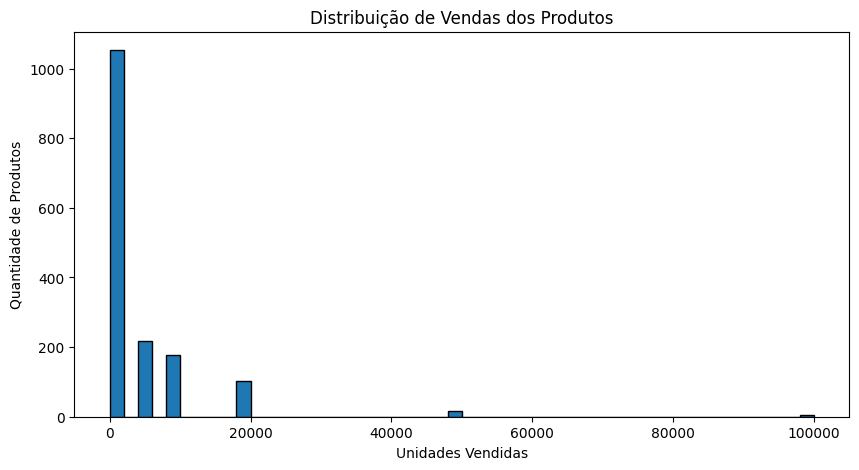

In [8]:
import matplotlib.pyplot as plt

# Gráfico da distribuição de vendas
plt.figure(figsize=(10, 5))
plt.hist(df['units_sold'], bins=50, edgecolor='black')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Quantidade de Produtos')
plt.title('Distribuição de Vendas dos Produtos')
plt.savefig('graficos/distribuicao_vendas.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Cria a coluna
df['is_bestseller'] = df['units_sold'] > 600

# Conta quantos best-sellers tem
print(df['is_bestseller'].value_counts())

is_bestseller
True     925
False    648
Name: count, dtype: int64


In [7]:
# Compara preço entre best-sellers e não best-sellers
df.groupby('is_bestseller')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
is_bestseller,,,,,,,,
False,648.0,8.10483,4.488589,1.0,5.0,8.0,11.0,49.0
True,925.0,8.47987,3.483959,1.0,6.0,8.0,11.0,24.0
